Hello Owen

Hello it is Matthieu

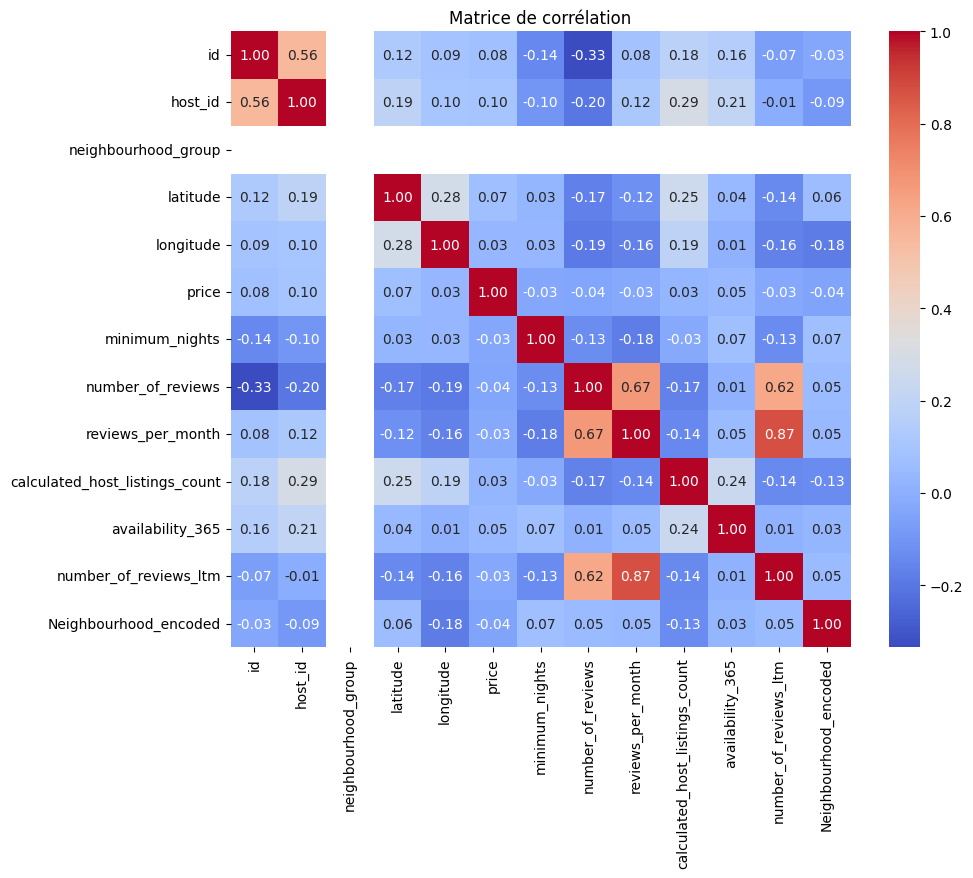

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("listings.csv")
encoder = LabelEncoder()
df['Neighbourhood_encoded'] = encoder.fit_transform(df['neighbourhood'])
corr = df.select_dtypes(include='number').corr()
#print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


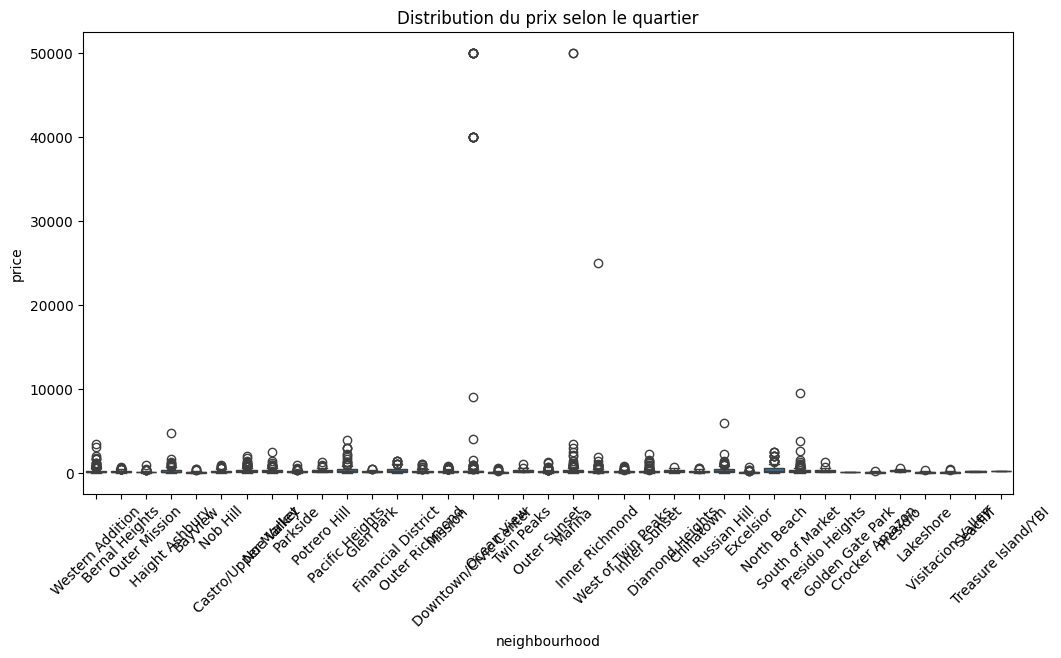

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='neighbourhood', y='price', data=df)
plt.title('Distribution du prix selon le quartier')
plt.xticks(rotation=45)
plt.show()


Statistique F = 2.5121889736431493
p-value = 1.6138530938096141e-06


C:\Users\matth\AppData\Local\Temp\ipykernel_29544\2202348285.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_prices.index, y=mean_prices.values, palette="coolwarm")


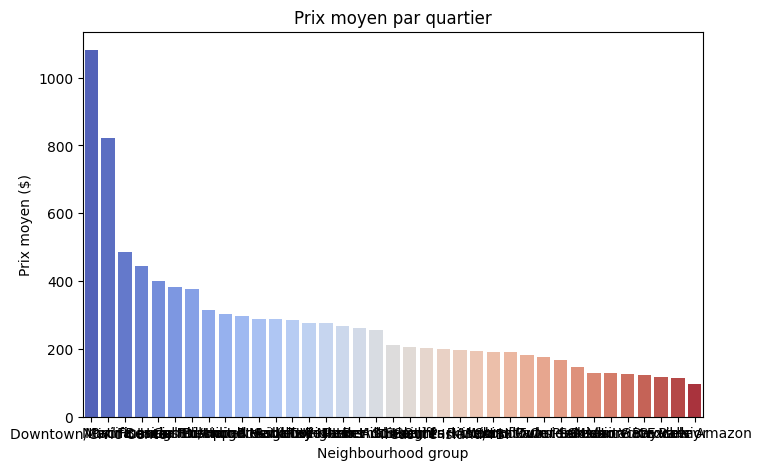

In [16]:
from scipy.stats import f_oneway

groups = [group["price"].dropna().values for name, group in df.groupby("neighbourhood")]
f_stat, p_value = f_oneway(*groups)
print("Statistique F =", f_stat)
print("p-value =", p_value)

mean_prices = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=mean_prices.index, y=mean_prices.values, palette="coolwarm")
plt.title('Prix moyen par quartier')
plt.ylabel('Prix moyen ($)')
plt.xlabel('Neighbourhood group')
plt.show()


In [22]:
import sys
print(sys.executable)


import pandas as pd
import folium
import branca.colormap as cm

# Charger le dataset
df = pd.read_csv("listings.csv")

# Calculer statistiques par quartier
stats = df.groupby('neighbourhood').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'price': 'mean',
    'id': 'count'  # nombre de listings
}).reset_index()
stats.rename(columns={'id':'num_listings'}, inplace=True)

# Créer carte centrée sur NY
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Créer une échelle de couleur pour le prix
colormap = cm.LinearColormap(colors=['green','yellow','red'],
                             vmin=stats['price'].min(),
                             vmax=stats['price'].max())
colormap.caption = 'Prix moyen ($)'
colormap.add_to(m)

# Ajouter cercles pour chaque quartier
for _, row in stats.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5 + row['num_listings']**0.5,  # taille selon nombre de listings
        color=colormap(row['price']),
        fill=True,
        fill_color=colormap(row['price']),
        fill_opacity=0.7,
        popup=(f"{row['neighbourhood']}<br>"
               f"Prix moyen: ${row['price']:.2f}<br>"
               f"Nombre de listings: {row['num_listings']}")
    ).add_to(m)

# Sauvegarder la carte interactive
m.save("airbnb_neighbourhood_map.html")


c:\Users\matth\OneDrive\Bureau\CS229\Project\.conda\python.exe


ModuleNotFoundError: No module named 'folium'